# Non-Reversible Parallel Tempering

In Notebook 04 we saw that single-chain Gibbs sampling fails for multimodal distributions — the chain gets stuck in one energy basin. **Parallel tempering** (PT) solves this by running multiple chains at different temperatures and **swapping** states between them.

This notebook covers:
- The parallel tempering idea and why it works
- **Deterministic Even-Odd (DEO)** swaps — non-reversible is better
- Round trip diagnostics: Λ, τ, efficiency
- **Adaptive schedule optimization** — concentrate chains where they matter
- **Automatic chain count discovery**
- Head-to-head: naive vs optimized vs more chains
- Full pipeline: discover → adapt → sample

The algorithms are based on Syed et al. (2021), "Non-Reversible Parallel Tempering: a Scalable Highly Parallel MCMC Scheme" ([arXiv:1905.02939](https://arxiv.org/abs/1905.02939)).

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time

from hamon import SpinNode, Block, NRPTStateObserver

from hamon.models.ising import IsingEBM, IsingSamplingProgram, hinton_init
from hamon.nrpt import nrpt, nrpt_adaptive, discover_chain_count

## Helper: build an L×L Ising grid

We'll reuse this throughout the notebook. Checkerboard coloring gives us two blocks for parallel Gibbs updates.

In [2]:
def make_ising_grid(L, coupling=1.0, field=0.0):
    """LxL nearest-neighbor Ising model with checkerboard blocking."""
    nodes_2d = [[SpinNode() for _ in range(L)] for _ in range(L)]
    nodes = [n for row in nodes_2d for n in row]
    edges = []
    for i in range(L):
        for j in range(L):
            if j + 1 < L:
                edges.append((nodes_2d[i][j], nodes_2d[i][j + 1]))
            if i + 1 < L:
                edges.append((nodes_2d[i][j], nodes_2d[i + 1][j]))
    biases = jnp.ones(len(nodes)) * field
    weights = jnp.ones(len(edges)) * coupling
    even = [nodes_2d[i][j] for i in range(L) for j in range(L) if (i + j) % 2 == 0]
    odd = [nodes_2d[i][j] for i in range(L) for j in range(L) if (i + j) % 2 == 1]
    free_blocks = [Block(even), Block(odd)]
    return nodes, nodes_2d, edges, biases, weights, free_blocks

## The multimodality problem

At low temperature, the ferromagnetic Ising model has two deep energy minima (all +1 and all -1). A single Gibbs chain can't cross the barrier between them.

**The parallel tempering idea:**
- Run $N$ chains at different inverse temperatures $\beta_0 < \beta_1 < \ldots < \beta_{N-1}$
- The **hot chain** ($\beta_0 \approx 0$) explores freely — it can cross barriers
- The **cold chain** ($\beta_{N-1}$ = target) samples from the distribution we care about
- **Swap** states between adjacent chains — hot-chain exploration propagates down to cold

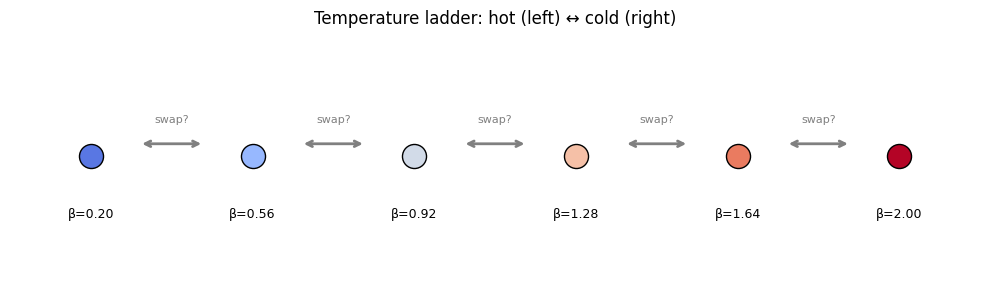

In [3]:
# Schematic: temperature ladder
fig, ax = plt.subplots(figsize=(10, 3))
n_demo = 6
betas_demo = np.linspace(0.2, 2.0, n_demo)

for i, b in enumerate(betas_demo):
    color = plt.cm.coolwarm(b / 2.0)
    ax.scatter(i, 0, s=300, color=color, zorder=5, edgecolors="black")
    ax.text(i, -0.15, f"\u03b2={b:.2f}", ha="center", fontsize=9)
    if i < n_demo - 1:
        ax.annotate(
            "",
            xy=(i + 0.7, 0.03),
            xytext=(i + 0.3, 0.03),
            arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
        )
        ax.text(i + 0.5, 0.08, "swap?", ha="center", fontsize=8, color="gray")

ax.set_xlim(-0.5, n_demo - 0.5)
ax.set_ylim(-0.3, 0.3)
ax.set_title("Temperature ladder: hot (left) \u2194 cold (right)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Setup: 16×16 ferromagnetic Ising model

We use a 16×16 ferromagnet with target $\beta = 1.0$ (past the critical point $\beta_c \approx 0.44$). At this temperature the system is in the ordered phase with two degenerate ground states separated by a free-energy barrier at the phase transition.

In [4]:
L = 16
nodes, nodes_2d, edges, biases, weights, free_blocks = make_ising_grid(L, coupling=1.0)

print(f"Ferromagnet: {L}x{L} = {L * L} spins, {len(edges)} edges (all J=+1)")
print("Target \u03b2 = 1.0  (\u03b2_c ~ 0.44)")

Ferromagnet: 16x16 = 256 spins, 480 edges (all J=+1)
Target β = 1.0  (β_c ~ 0.44)


## Basic NRPT with `nrpt`

The `nrpt` function runs non-reversible parallel tempering. We need:
- A list of EBMs (one per chain, at different $\beta$ values)
- A list of sampling programs
- Initial states for each chain

hamon exploits **temperature linearity** of the Ising energy: $E_\beta = \beta \cdot E_{\text{base}}$. This means swap decisions need only **one energy evaluation per chain** instead of four per pair.

In [5]:
n_chains = 8
betas = jnp.linspace(0.3, 1.0, n_chains)

ebms = [IsingEBM(nodes, edges, biases, weights, jnp.array(float(b))) for b in betas]
programs = [IsingSamplingProgram(e, free_blocks, []) for e in ebms]

key = jax.random.key(42)
keys = jax.random.split(key, n_chains + 1)
init_states = [hinton_init(keys[i], ebms[0], free_blocks, ()) for i in range(n_chains)]

states, stats = nrpt(
    keys[-1],
    ebms,
    programs,
    init_states,
    clamp_state=[],
    n_rounds=500,
    gibbs_steps_per_round=5,
)

print(f"Chains: {n_chains}")
print(f"Betas:  {[f'{b:.3f}' for b in betas]}")
print(f"Rejection rates:  {[f'{float(r):.3f}' for r in stats['rejection_rates']]}")

Chains: 8
Betas:  ['0.300', '0.400', '0.500', '0.600', '0.700', '0.800', '0.900', '1.000']
Rejection rates:  ['0.968', '0.988', '0.924', '0.732', '0.484', '0.316', '0.204']


## DEO swaps explained

hamon uses **Deterministic Even-Odd (DEO)** swaps, which are key to non-reversibility:

- **Even rounds**: attempt swaps between pairs (0,1), (2,3), (4,5), ...
- **Odd rounds**: attempt swaps between pairs (1,2), (3,4), (5,6), ...
- The parity alternates deterministically: even, odd, even, odd, ...

This is **non-reversible** because the sequence even→odd→even is not the same forwards and backwards. Syed et al. (2021) proved this gives strictly better round trip rates than random swaps.

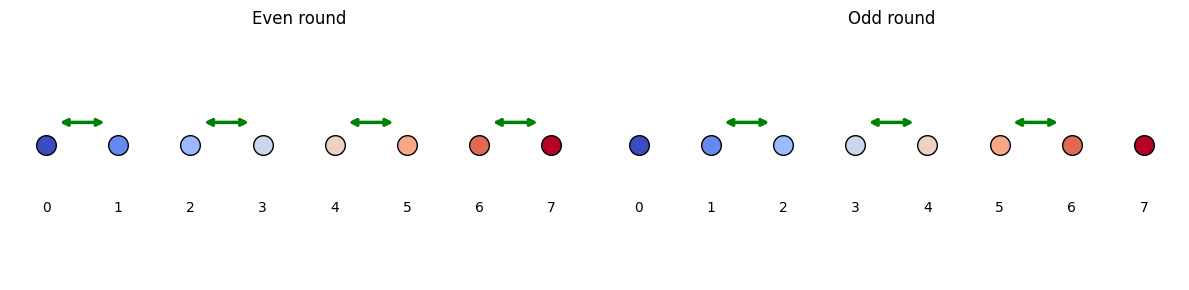

In [6]:
# Visualize the DEO swap pattern
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

for ax, parity, title in zip(axes, ["even", "odd"], ["Even round", "Odd round"]):
    for i in range(n_chains):
        ax.scatter(
            i,
            0,
            s=200,
            color=plt.cm.coolwarm(i / (n_chains - 1)),
            edgecolors="black",
            zorder=5,
        )
        ax.text(i, -0.15, f"{i}", ha="center", fontsize=10)

    if parity == "even":
        swap_pairs = [(i, i + 1) for i in range(0, n_chains - 1, 2)]
    else:
        swap_pairs = [(i, i + 1) for i in range(1, n_chains - 1, 2)]

    for a, b in swap_pairs:
        ax.annotate(
            "",
            xy=(b - 0.15, 0.05),
            xytext=(a + 0.15, 0.05),
            arrowprops=dict(arrowstyle="<->", color="green", lw=2.5),
        )

    ax.set_xlim(-0.5, n_chains - 0.5)
    ax.set_ylim(-0.3, 0.25)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Round trip diagnostics

The quality of parallel tempering is measured by how efficiently information flows from hot to cold chains:

- **$\Lambda$** (global communication barrier): sum of local barriers. Higher $\Lambda$ = harder problem.
- **$\tau_{\text{predicted}}$**: theoretical optimal round trip rate = $1/(2 + 2\Lambda)$
- **$\tau_{\text{observed}}$**: actual round trip rate from tracking the index process
- **Efficiency**: $\tau_{\text{observed}} / \tau_{\text{predicted}}$ — how close to optimal

In [7]:
diag = stats["round_trip_diagnostics"]

print("Round trip diagnostics")
print(f"  Global barrier \u039b:       {float(diag['Lambda']):.4f}")
print(f"  Predicted \u03c4 = 1/(2+2\u039b): {float(diag['tau_predicted']):.4f}")
print(f"  Observed \u03c4:             {float(diag['tau_observed']):.4f}")
print(f"  Efficiency (\u03c4_obs/\u03c4):   {float(diag['efficiency']):.4f}")
print()
print(f"  Round trips per machine: {diag['round_trips_per_chain'].tolist()}")
print(f"  Restarts per machine:    {diag['restarts_per_chain'].tolist()}")

Round trip diagnostics
  Global barrier Λ:       4.6160
  Predicted τ = 1/(2+2Λ): 0.0890
  Observed τ:             0.0020
  Efficiency (τ_obs/τ):   0.0225

  Round trips per machine: [1, 0, 0, 0, 0, 0, 0, 0]
  Restarts per machine:    [1, 0, 1, 1, 1, 1, 1, 1]


## Communication barrier $\lambda(\beta)$

The local communication barrier $\lambda(\beta)$ measures how hard it is to swap at each temperature. Peaks in $\lambda(\beta)$ indicate where the schedule needs more chains. For the 2D Ising model, this peaks near the critical temperature $\beta_c \approx 0.44$.

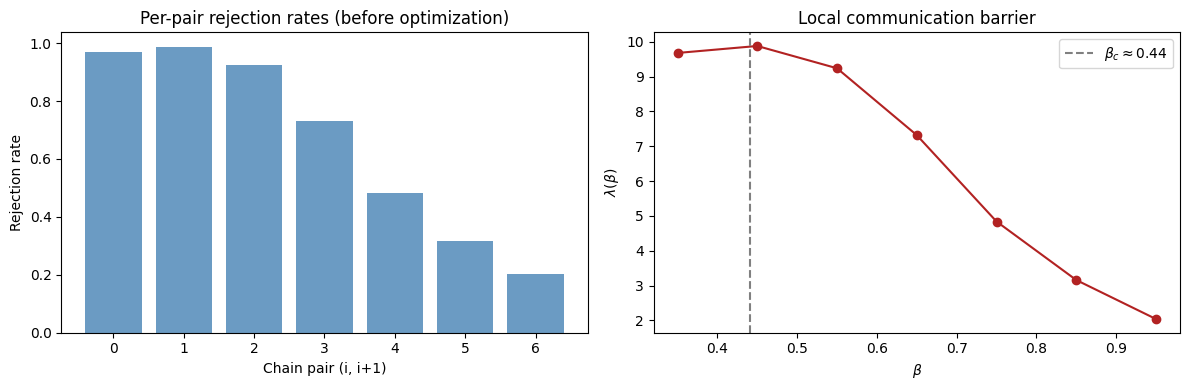

In [8]:
lambda_profile = diag["lambda_profile"]
beta_midpoints = (betas[:-1] + betas[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    range(len(stats["rejection_rates"])),
    np.array(stats["rejection_rates"]),
    color="steelblue",
    alpha=0.8,
)
axes[0].set_xlabel("Chain pair (i, i+1)")
axes[0].set_ylabel("Rejection rate")
axes[0].set_title("Per-pair rejection rates (before optimization)")

axes[1].plot(
    np.array(beta_midpoints), np.array(lambda_profile), "o-", color="firebrick"
)
axes[1].axvline(0.4407, color="gray", ls="--", label="$\\beta_c \\approx 0.44$")
axes[1].set_xlabel("$\\beta$")
axes[1].set_ylabel("$\\lambda(\\beta)$")
axes[1].set_title("Local communication barrier")
axes[1].legend()

plt.tight_layout()
plt.show()

## Adaptive schedule optimization with `nrpt_adaptive`

A uniform $\beta$ schedule wastes chains in easy regions while starving the bottleneck at $\beta_c$. The **adaptive** algorithm (Algorithm 4 from Syed et al.) iteratively adjusts the schedule so that rejection rates are equalized across all pairs. This minimizes $\Lambda$.

In [9]:
ebm = IsingEBM(nodes, edges, biases, weights, jnp.array(1.0))
program = IsingSamplingProgram(ebm, free_blocks, [])

key_adapt = jax.random.key(42)
initial_betas = jnp.linspace(0.3, 1.0, n_chains)

states_adapt, stats_adapt = nrpt_adaptive(
    key_adapt,
    init_states=init_states,
    clamp_state=[],
    n_rounds=500,
    gibbs_steps_per_round=10,
    initial_betas=initial_betas,
    n_tune=8,
    rounds_per_tune=200,
    ebm=ebm,
    program=program,
)

In [10]:
print("Schedule optimization results")
print(f"  Initial betas: {[f'{b:.3f}' for b in initial_betas]}")
print(f"  Final betas:   {[f'{float(b):.3f}' for b in stats_adapt['betas']]}")
print(
    f"  Final rejection rates: {[f'{float(r):.3f}' for r in stats_adapt['rejection_rates']]}"
)
print()
diag_adapt = stats_adapt["round_trip_diagnostics"]
print(f"  \u039b (after opt):  {float(diag_adapt['Lambda']):.4f}")
print(f"  \u03c4 predicted:    {float(diag_adapt['tau_predicted']):.4f}")
print(f"  \u03c4 observed:     {float(diag_adapt['tau_observed']):.4f}")
print(f"  Round trips:    {diag_adapt['round_trips_per_chain'].tolist()}")

Schedule optimization results
  Initial betas: ['0.300', '0.400', '0.500', '0.600', '0.700', '0.800', '0.900', '1.000']
  Final betas:   ['0.300', '0.364', '0.421', '0.470', '0.521', '0.594', '0.705', '1.000']
  Final rejection rates: ['0.800', '0.852', '0.780', '0.780', '0.816', '0.784', '0.828']

  Λ (after opt):  5.6400
  τ predicted:    0.0753
  τ observed:     0.0100
  Round trips:    [1, 2, 0, 0, 1, 0, 1, 0]


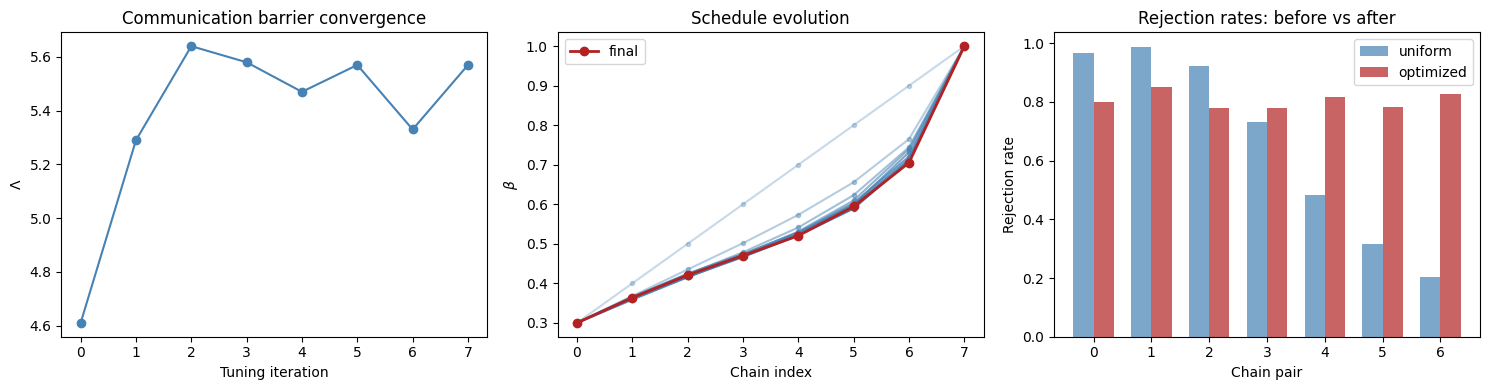

In [11]:
history = stats_adapt["tuning_history"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lambdas = [h["Lambda"] for h in history]
axes[0].plot(range(len(lambdas)), lambdas, "o-", color="steelblue")
axes[0].set_xlabel("Tuning iteration")
axes[0].set_ylabel("$\\Lambda$")
axes[0].set_title("Communication barrier convergence")

for i, h in enumerate(history):
    alpha = 0.3 + 0.7 * (i / max(len(history) - 1, 1))
    axes[1].plot(
        range(n_chains),
        np.array(h["betas"]),
        "o-",
        alpha=alpha,
        color="steelblue",
        markersize=3,
    )
axes[1].plot(
    range(n_chains),
    np.array(stats_adapt["betas"]),
    "o-",
    color="firebrick",
    label="final",
    linewidth=2,
)
axes[1].set_xlabel("Chain index")
axes[1].set_ylabel("$\\beta$")
axes[1].set_title("Schedule evolution")
axes[1].legend()

x = np.arange(n_chains - 1)
w = 0.35
axes[2].bar(
    x - w / 2,
    np.array(stats["rejection_rates"]),
    w,
    label="uniform",
    color="steelblue",
    alpha=0.7,
)
axes[2].bar(
    x + w / 2,
    np.array(stats_adapt["rejection_rates"]),
    w,
    label="optimized",
    color="firebrick",
    alpha=0.7,
)
axes[2].set_xlabel("Chain pair")
axes[2].set_ylabel("Rejection rate")
axes[2].set_title("Rejection rates: before vs after")
axes[2].legend()

plt.tight_layout()
plt.show()

## Automatic chain count discovery

How many chains do we need? Too few and swaps are rejected too often; too many wastes computation. `discover_chain_count` iteratively probes different chain counts to find the right number.

The bootstrapping problem: $\Lambda$ estimated with too few chains is biased low (the coarse schedule can't resolve the peak in $\lambda(\beta)$). The discovery algorithm handles this by iteratively refining.

In [12]:
def init_factory(n_chains, ebms_list, programs_list):
    """Create initial states for a given number of chains."""
    fb = programs_list[0].gibbs_spec.free_blocks
    ks = jax.random.split(jax.random.key(0), n_chains)
    return [hinton_init(ks[i], ebms_list[0], fb, ()) for i in range(n_chains)]


disc_key = jax.random.key(42)
discovery = discover_chain_count(
    disc_key,
    init_factory=init_factory,
    clamp_state=[],
    beta_range=(0.3, 1.0),
    gibbs_steps_per_round=10,
    initial_n=4,
    target_acceptance=0.6,
    ebm=ebm,
    program=program,
)

print("=== Chain Count Discovery ===")
print(f"Final chain count: {discovery['n_chains']}")
print(f"Barrier estimate \u039b: {discovery['Lambda']:.4f}")
print(f"Convergence reason: {discovery['converged_reason']}")
print("\nDiscovery history:")
for entry in discovery["history"]:
    print(
        f"  Iter {entry['iteration']}: n={entry['n']}, \u039b_raw={entry['Lambda_raw']:.3f}, "
        f"\u039b_max={entry['Lambda_max']:.3f}, n_rec={entry['n_recommended']}"
    )

=== Chain Count Discovery ===
Final chain count: 16
Barrier estimate Λ: 6.7576
Convergence reason: max_iters

Discovery history:
  Iter 0: n=4, Λ_raw=2.909, Λ_max=2.909, n_rec=8
  Iter 1: n=6, Λ_raw=4.455, Λ_max=4.455, n_rec=12
  Iter 2: n=9, Λ_raw=5.121, Λ_max=5.121, n_rec=13
  Iter 3: n=11, Λ_raw=5.424, Λ_max=5.424, n_rec=14
  Iter 4: n=13, Λ_raw=6.758, Λ_max=6.758, n_rec=17
  Iter 5: n=15, Λ_raw=6.700, Λ_max=6.758, n_rec=17


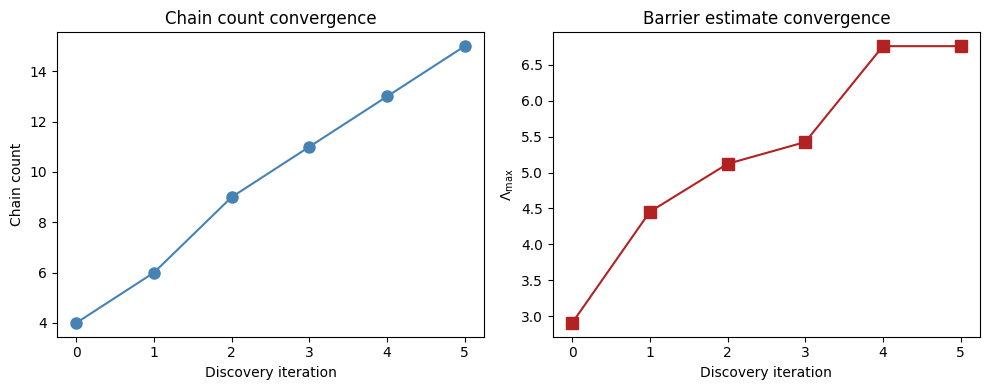

In [13]:
# Plot discovery convergence
hist = discovery["history"]
iters = [e["iteration"] for e in hist]
ns = [e["n"] for e in hist]
lambdas_disc = [e["Lambda_max"] for e in hist]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(iters, ns, "o-", color="steelblue", markersize=8)
axes[0].set_xlabel("Discovery iteration")
axes[0].set_ylabel("Chain count")
axes[0].set_title("Chain count convergence")

axes[1].plot(iters, lambdas_disc, "s-", color="firebrick", markersize=8)
axes[1].set_xlabel("Discovery iteration")
axes[1].set_ylabel("$\\Lambda_{\\max}$")
axes[1].set_title("Barrier estimate convergence")

plt.tight_layout()
plt.show()

## Head-to-head: naive vs optimized vs more chains

Everything above builds toward a single question: **does this actually help?** Let's run the same model with three configurations and compare:

- **Naive**: uniform $\beta$ spacing, no schedule tuning, 8 chains
- **Optimized**: adaptive schedule, 16 chains
- **Naive (16 chains)**: double the chains, still uniform spacing

The punchline: optimization with 16 chains should beat naive with 16.

In [14]:
# Fresh model so all three configs use identical graphs
L_cmp = 16
nodes_cmp, nodes_2d_cmp, edges_cmp, biases_cmp, weights_cmp, fb_cmp = make_ising_grid(
    L_cmp, coupling=1.0
)

N_ROUNDS = 600
GIBBS_STEPS = 50


def run_experiment(key, betas_arr, label):
    """Run NRPT and collect timing + diagnostics."""
    nc = len(betas_arr)
    ebm_list = [
        IsingEBM(nodes_cmp, edges_cmp, biases_cmp, weights_cmp, jnp.array(float(b)))
        for b in betas_arr
    ]
    prog_list = [IsingSamplingProgram(e, fb_cmp, []) for e in ebm_list]
    ks = jax.random.split(jax.random.key(0), nc + 1)
    inits = [hinton_init(ks[i], ebm_list[0], fb_cmp, ()) for i in range(nc)]

    # Warmup (compile)
    _ = nrpt(
        ks[-1], ebm_list, prog_list, inits, [], n_rounds=2, gibbs_steps_per_round=1
    )

    k_run = jax.random.key(
        {"Naive (8 chains)": 1, "Optimized (16 chains)": 2, "Naive (16 chains)": 3}[
            label
        ]
    )
    t0 = time.perf_counter()
    _, st = nrpt(
        k_run,
        ebm_list,
        prog_list,
        inits,
        [],
        n_rounds=N_ROUNDS,
        gibbs_steps_per_round=GIBBS_STEPS,
    )
    jax.block_until_ready(st["accepted"])
    elapsed = time.perf_counter() - t0

    d = st["round_trip_diagnostics"]
    return {
        "label": label,
        "n_chains": nc,
        "elapsed": elapsed,
        "Lambda": float(d["Lambda"]),
        "tau_predicted": float(d["tau_predicted"]),
        "tau_observed": float(d["tau_observed"]),
        "efficiency": float(d["efficiency"]),
        "total_round_trips": int(jnp.sum(d["round_trips_per_chain"])),
        "rejection_rates": np.array(st["rejection_rates"]),
        "betas": np.array(st["betas"]),
    }

In [15]:
# Template EBM and program for the comparison grid
cmp_ebm = IsingEBM(nodes_cmp, edges_cmp, biases_cmp, weights_cmp, jnp.array(1.0))
cmp_prog = IsingSamplingProgram(cmp_ebm, fb_cmp, [])

# A: Naive, 8 chains, uniform beta
result_naive = run_experiment(
    jax.random.key(42), jnp.linspace(0.3, 1.0, 8), "Naive (8 chains)"
)

# B: Optimized, 16 chains -- run adaptive on the comparison grid
key_opt16 = jax.random.key(42)
ks_opt = jax.random.split(key_opt16, 17)
# Build initial EBMs at uniform betas to get init states
init_betas_16 = jnp.linspace(0.3, 1.0, 16)
init_ebms_16 = [cmp_ebm.with_beta(jnp.array(float(b))) for b in init_betas_16]
inits_opt16 = [hinton_init(ks_opt[i], init_ebms_16[0], fb_cmp, ()) for i in range(16)]
_, stats_opt16 = nrpt_adaptive(
    ks_opt[-1],
    init_states=inits_opt16,
    clamp_state=[],
    n_rounds=100,
    gibbs_steps_per_round=5,
    initial_betas=init_betas_16,
    n_tune=8,
    rounds_per_tune=100,
    ebm=cmp_ebm,
    program=cmp_prog,
)
result_opt = run_experiment(
    jax.random.key(42), stats_opt16["betas"], "Optimized (16 chains)"
)

# C: Naive, 16 chains, uniform beta
result_more = run_experiment(
    jax.random.key(42), jnp.linspace(0.3, 1.0, 16), "Naive (16 chains)"
)

results = [result_naive, result_opt, result_more]

In [16]:
# Comparison table
col_w = 14
hdr = f"{'':32s} {'Naive 8':>{col_w}s} {'Opt 16':>{col_w}s} {'Naive 16':>{col_w}s}"
print(hdr)
print("-" * len(hdr))

fields = [
    ("Chains", "n_chains", "d"),
    ("Wall time (s)", "elapsed", ".2f"),
    ("Barrier \u039b", "Lambda", ".4f"),
    ("\u03c4 predicted", "tau_predicted", ".4f"),
    ("\u03c4 observed", "tau_observed", ".4f"),
    ("Efficiency (\u03c4/\u03c4\u0304)", "efficiency", ".2%"),
    ("Total round trips", "total_round_trips", "d"),
    ("Round trips / sec", None, ".1f"),
]

for label, key_name, fmt in fields:
    vals = []
    for r in results:
        if key_name is None:
            v = r["total_round_trips"] / max(r["elapsed"], 1e-9)
        else:
            v = r[key_name]
        vals.append(f"{v:{fmt}}")
    print(f"{label:32s} {vals[0]:>{col_w}s} {vals[1]:>{col_w}s} {vals[2]:>{col_w}s}")

                                        Naive 8         Opt 16       Naive 16
-----------------------------------------------------------------------------
Chains                                        8             16             16
Wall time (s)                              1.17           2.13           2.15
Barrier Λ                                4.6667         6.4933         6.0800
τ predicted                              0.0882         0.0667         0.0706
τ observed                               0.0050         0.0500         0.0283
Efficiency (τ/τ̄)                         5.67%         74.93%         40.12%
Total round trips                             3             30             17
Round trips / sec                           2.6           14.1            7.9


## Full pipeline: discover → adapt → sample

Let's put it all together: use `discover_chain_count` to find the right number of chains, then `nrpt_adaptive` to optimize the schedule and collect production samples from the cold chain.

In [17]:
# Collect samples using NRPT observer
n_production_rounds = 5000
n_opt = discovery["n_chains"]
init_betas = jnp.linspace(0.3, 1.0, n_opt)

key_pipe = jax.random.key(42)
k_tune, k_prod = jax.random.split(key_pipe)

# First: tune the schedule
init_ebms = [ebm.with_beta(jnp.array(float(b))) for b in init_betas]
init_progs = [program.with_ebm(e) for e in init_ebms]
init_opt = init_factory(n_opt, init_ebms, init_progs)

states_tuned, stats_tuned = nrpt_adaptive(
    k_tune,
    init_states=init_opt,
    clamp_state=[],
    n_rounds=50,
    gibbs_steps_per_round=10,
    initial_betas=init_betas,
    n_tune=8,
    rounds_per_tune=100,
    ebm=ebm,
    program=program,
)

# Production: single nrpt call with observer collects all cold-chain states
opt_betas = stats_tuned["betas"]
opt_ebms = [ebm.with_beta(jnp.array(float(b))) for b in opt_betas]
opt_progs = [program.with_ebm(e) for e in opt_ebms]

obs = NRPTStateObserver(chain_indices=(-1,))

_, stats_prod = nrpt(
    k_prod,
    opt_ebms,
    opt_progs,
    states_tuned,
    [],
    n_rounds=n_production_rounds,
    gibbs_steps_per_round=10,
    betas=opt_betas,
    observer=obs,
)

# observations is a list of arrays, one per block, each (n_rounds, 1, ...)
# Squeeze out the chain dim and flatten across blocks
cold_per_block = [arr[:, 0] for arr in stats_prod["observations"]]
final_samples = jnp.concatenate(
    [c.reshape(n_production_rounds, -1) for c in cold_per_block], axis=1
)

rt_final = stats_prod["round_trip_diagnostics"]
print(f"Chains used: {n_opt}")

print(f"Round trips: {rt_final['round_trips_per_chain']}")
print(f"τ predicted: {float(rt_final['tau_predicted']):.4f}")
print(f"Rejection rates: {[f'{float(r):.3f}' for r in stats_prod['rejection_rates']]}")
print(f"Final samples: {final_samples.shape}")
print(f"Final Λ: {float(rt_final['Lambda']):.4f}")
print(f"Final efficiency: {float(rt_final['efficiency']):.4f}")

Chains used: 16
Round trips: [13  7  8  9 13 11  9 11  8 12 15 11 13 12  9 10]
τ predicted: 0.0662
Rejection rates: ['0.461', '0.503', '0.428', '0.432', '0.450', '0.429', '0.430', '0.449', '0.386', '0.400', '0.546', '0.404', '0.427', '0.428', '0.382']
Final samples: (5000, 256)
Final Λ: 6.5560
Final efficiency: 0.5168


Convergence status: NEED_MORE
Marginal entropy: 1.0000

Note: convergence reports 'NEED_MORE' and rank stability is meaningless here
because this is a symmetric ferromagnet — all 256 spins have identical marginals.
The entropy of ~1.0 is the meaningful diagnostic: PT is sampling both modes.


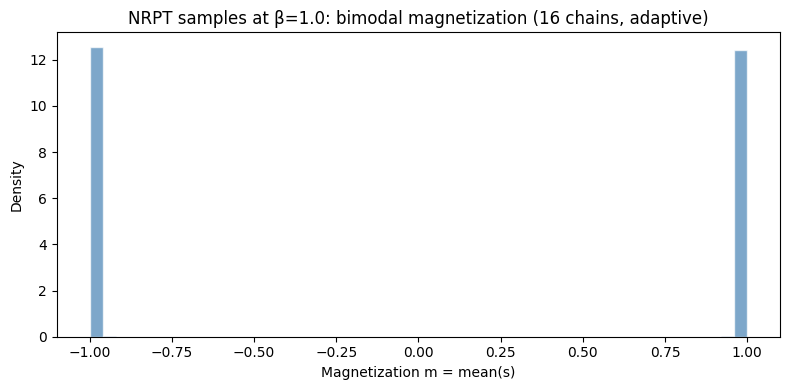

In [18]:
# Verify sample quality
from hamon.diagnostics import sample_convergence, marginal_entropy

report = sample_convergence(final_samples)
entropy = marginal_entropy(final_samples)

print(f"Convergence status: {report.status}")
print(f"Marginal entropy: {entropy:.4f}")
print()
print("Note: convergence reports 'NEED_MORE' and rank stability is meaningless here")
print(
    "because this is a symmetric ferromagnet — all 256 spins have identical marginals."
)
print("The entropy of ~1.0 is the meaningful diagnostic: PT is sampling both modes.")

# Magnetization histogram
spins = 2.0 * final_samples.astype(float) - 1.0  # bool -> +/-1
mag = spins.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mag, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="white")
ax.set_xlabel("Magnetization m = mean(s)")
ax.set_ylabel("Density")
ax.set_title(f"NRPT samples at β=1.0: bimodal magnetization ({n_opt} chains, adaptive)")
plt.tight_layout()
plt.show()

## Summary

- **Parallel tempering** overcomes energy barriers by running chains at multiple temperatures and swapping states
- **DEO swaps** (deterministic even-odd) provide non-reversibility, improving round trip rates over random swaps
- hamon exploits **temperature linearity** for efficient swap decisions (one energy eval per chain)
- **Round trip diagnostics** ($\Lambda$, $\tau$, efficiency) quantify sampling quality
- **Adaptive schedule optimization** concentrates chains near the phase transition bottleneck, reducing $\Lambda$
- **Chain count discovery** automatically finds the right number of chains
- The head-to-head comparison shows that **optimized 16 chains beats naive 16 chains** — smart scheduling matters more than raw chain count